In [6]:
import os
from scipy.ndimage import gaussian_filter, laplace
import cv2
import shutil
import math
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import loralib as lora
from einops import rearrange
from torch.utils.data import Dataset, DataLoader
from torchinfo import summary
from torchmetrics import Precision, Recall
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score
from albumentations import (
    Compose, OneOf, HorizontalFlip, VerticalFlip, Rotate, RandomGamma, ElasticTransform, 
    GridDistortion, OpticalDistortion, RGBShift, InvertImg,CLAHE, RandomBrightnessContrast,
    GaussNoise, RandomResizedCrop, HueSaturationValue, Blur, ShiftScaleRotate)

In [7]:
dataset = "DeepCrack"  # Change this to switch between datasets: Crack500, DeepCrack, Edmdata

# Directories for images and masks
if dataset == "Crack500":
    image_dir = r'/home/abid/Crack500/Image'
    mask_dir = r'/home/abid/Crack500/Mask'
elif dataset == "DeepCrack":
    image_dir = r'./DeepCrack/Image'
    mask_dir = r'./DeepCrack/Mask'
elif dataset == "CFD_dataset":
    image_dir = r'/home/abid/CFD_dataset/CFD_dataset/Image'
    mask_dir = r'/home/abid/CFD_dataset/CFD_dataset/Mask'
elif dataset == "CrackSC_dataset":
    image_dir = r'/Users/abid/crack_seg/data_3/DeepCrack/Image'
    mask_dir = r'/Users/abid/crack_seg/data_3/DeepCrack/Mask'
elif dataset == "gap":
    image_dir = '/home/abid/gap/Image'
    mask_dir = '/home/abid/gap/Mask'
else:
    raise ValueError("Unknown dataset")
# Get all image and mask paths
image_paths = sorted([os.path.join(image_dir, fname) for fname in os.listdir(image_dir) 
                      if (fname.endswith(".jpg") or fname.endswith(".png")) and not fname.startswith(".")])
mask_paths = sorted([os.path.join(mask_dir, fname) for fname in os.listdir(mask_dir) 
                     if (fname.endswith(".png") or fname.endswith(".jpg")) and not fname.startswith(".")])

# Shuffle the dataset
print(image_paths)
print(mask_paths)
combined = list(zip(image_paths, mask_paths))
random.shuffle(combined)
image_paths[:], mask_paths[:] = zip(*combined)

# Split the dataset indices
total_count = len(image_paths)
train_split = math.floor(total_count * 0.7)
val_split = math.floor(total_count * 0.15)

train_image_paths = image_paths[:train_split]
train_mask_paths = mask_paths[:train_split]

val_image_paths = image_paths[train_split:train_split + val_split]
val_mask_paths = mask_paths[train_split:train_split + val_split]

test_image_paths = image_paths[train_split + val_split:]
test_mask_paths = mask_paths[train_split + val_split:]

# Print the number of files in each split
print(f"Number of training images: {len(train_image_paths)}")
print(f"Number of validation images: {len(val_image_paths)}")
print(f"Number of testing images: {len(test_image_paths)}")

['./DeepCrack/Image/11111.jpg', './DeepCrack/Image/11112.jpg', './DeepCrack/Image/11113.jpg', './DeepCrack/Image/11114.jpg', './DeepCrack/Image/11115.jpg', './DeepCrack/Image/11116-1.jpg', './DeepCrack/Image/11116-2.jpg', './DeepCrack/Image/11116-3.jpg', './DeepCrack/Image/11116-4.jpg', './DeepCrack/Image/11116.jpg', './DeepCrack/Image/11117.jpg', './DeepCrack/Image/11118.jpg', './DeepCrack/Image/11119.jpg', './DeepCrack/Image/11120.jpg', './DeepCrack/Image/11121.jpg', './DeepCrack/Image/111212-1.jpg', './DeepCrack/Image/11122-1.jpg', './DeepCrack/Image/11122-2.jpg', './DeepCrack/Image/11122-3.jpg', './DeepCrack/Image/11122-4.jpg', './DeepCrack/Image/11122-5.jpg', './DeepCrack/Image/11122.jpg', './DeepCrack/Image/11123-1.jpg', './DeepCrack/Image/11123-2.jpg', './DeepCrack/Image/11123-3.jpg', './DeepCrack/Image/11123-4.jpg', './DeepCrack/Image/11123-5.jpg', './DeepCrack/Image/11123-6.jpg', './DeepCrack/Image/11123.jpg', './DeepCrack/Image/11124.jpg', './DeepCrack/Image/11125-1.jpg', './

In [8]:
batch_size = 8
img_dim = (256, 256)

In [9]:
class CrackDataset(Dataset):
    def __init__(self, image_paths, mask_paths, img_dim=(256, 256), augment=False):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.img_dim = img_dim
        self.augment = augment
        
        # Define augmentations
        self.augmentations = Compose([
            Rotate(p=0.7),
            RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.3),
            Blur(blur_limit=3, p=0.2),
            ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=10, p=0.3),
            GaussNoise(var_limit=(10.0, 50.0), p=0.2),
            InvertImg(p=0.2),
            ElasticTransform(alpha=1, sigma=50, alpha_affine=20, p=0.2),  # Fixed parameter
            GridDistortion(num_steps=5, distort_limit=0.3, p=0.32),
            RandomGamma(gamma_limit=(80, 120), p=0.3)
        ])
    
    # Rest of the class remains the same

    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        # Load image and mask
        image = cv2.imread(self.image_paths[idx], -1)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (self.img_dim[1], self.img_dim[0]))
        
        mask = cv2.imread(self.mask_paths[idx], -1)
        mask = cv2.resize(mask, (self.img_dim[1], self.img_dim[0]))
        mask = (mask > 0).astype(np.uint8)
        
        # Apply augmentations if needed
        if self.augment:
            augmented = self.augmentations(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']
        
        # Convert to PyTorch tensors
        image = image / 256.0  # Normalize to [0, 1]
        image = torch.from_numpy(image).permute(2, 0, 1).float()  # [H, W, C] -> [C, H, W]
        
        mask = torch.from_numpy(mask).unsqueeze(0).float()  # Add channel dimension [H, W] -> [1, H, W]
        
        return image, mask



In [10]:
# Initialize the datasets
train_dataset = CrackDataset(train_image_paths, train_mask_paths, img_dim=img_dim, augment=True)
val_dataset = CrackDataset(val_image_paths, val_mask_paths, img_dim=img_dim, augment=False)
test_dataset = CrackDataset(test_image_paths, test_mask_paths, img_dim=img_dim, augment=False)

# Initialize the dataloaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

# Print to verify the dataset initialization
print("Train dataset initialized with", len(train_dataset), "images.")
print("Validation dataset initialized with", len(val_dataset), "images.")
print("Test dataset initialized with", len(test_dataset), "images.")

Train dataset initialized with 368 images.
Validation dataset initialized with 79 images.
Test dataset initialized with 80 images.


/tmp/ipykernel_25883/1321476411.py:14: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  GaussNoise(var_limit=(10.0, 50.0), p=0.2),
/tmp/ipykernel_25883/1321476411.py:16: UserWarning: Argument(s) 'alpha_affine' are not valid for transform ElasticTransform
  ElasticTransform(alpha=1, sigma=50, alpha_affine=20, p=0.2),  # Fixed parameter


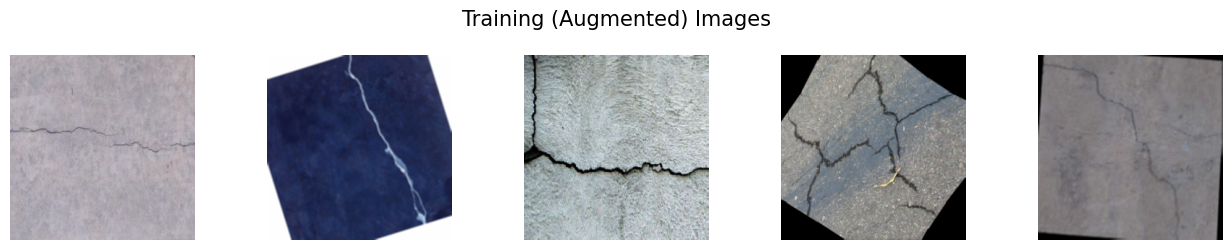

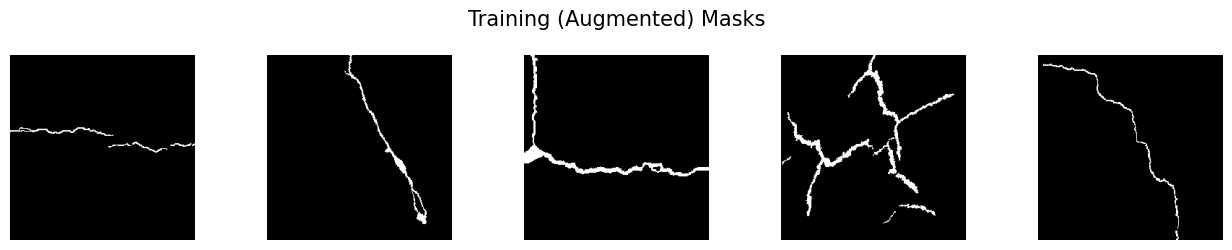

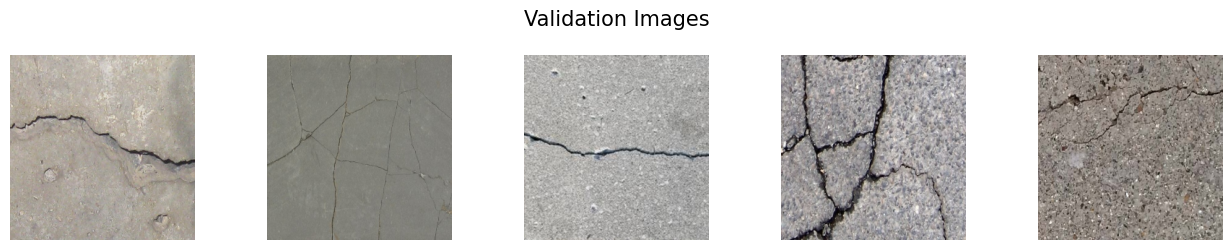

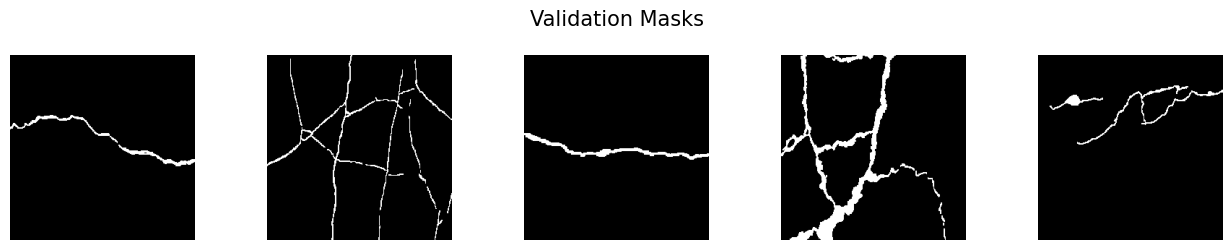

In [11]:
# Visualization function
def show_batch(data_loader, title, num_samples=5):
    # Get a batch
    images, masks = next(iter(data_loader))
    
    # Convert from tensor to numpy for visualization
    images = images.numpy().transpose(0, 2, 3, 1)[:num_samples]  # [B, C, H, W] -> [B, H, W, C]
    masks = masks.numpy()[:num_samples, 0]  # [B, 1, H, W] -> [B, H, W]
    
    # Display images
    fig, axes = plt.subplots(1, num_samples, figsize=(13, 2.5))
    fig.suptitle(f'{title} Images', fontsize=15)
    axes = axes.flatten()
    for img, ax in zip(images, axes):
        ax.imshow(img)
        ax.axis('off')
    plt.tight_layout()
    plt.show()
    
    # Display masks
    fig, axes = plt.subplots(1, num_samples, figsize=(13, 2.5))
    fig.suptitle(f'{title} Masks', fontsize=15)
    axes = axes.flatten()
    for img, ax in zip(masks, axes):
        ax.imshow(img, cmap='gray')
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# Visualize samples
show_batch(train_loader, 'Training (Augmented)')
show_batch(val_loader, 'Validation')

In [12]:
def conv_1x1_bn(inp, oup):
    return nn.Sequential(
        nn.Conv2d(inp, oup, 1, 1, 0, bias=False),
        nn.BatchNorm2d(oup),
        nn.SiLU()
    )


def conv_nxn_bn(inp, oup, kernel_size=3, stride=1):
    return nn.Sequential(
        nn.Conv2d(inp, oup, kernel_size, stride, 1, bias=False),
        nn.BatchNorm2d(oup),
        nn.SiLU()
    )


class PreNorm(nn.Module):
    def __init__(self, dim, fn):
        super().__init__()
        self.norm = nn.LayerNorm(dim)
        self.fn = fn
    
    def forward(self, x, **kwargs):
        return self.fn(self.norm(x), **kwargs)


class FeedForward(nn.Module):
    def __init__(self, dim, hidden_dim, dropout=0.):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, dim),
            nn.Dropout(dropout)
        )
    
    def forward(self, x):
        return self.net(x)


class Attention(nn.Module):
    def __init__(self, dim, heads=8, dim_head=64, lora_r= 2, dropout=0.):
        super().__init__()
        inner_dim = dim_head * heads
        project_out = not (heads == 1 and dim_head == dim)
        self.heads = heads
        self.scale = dim_head ** -0.5
        self.attend = nn.Softmax(dim=-1)
        # LoRA on Q and V
        self.to_qkv = lora.MergedLinear(dim, inner_dim * 3,
                                        r=lora_r,
                                        enable_lora=[True, False, True],
                                        bias=False)
        self.to_out = (nn.Sequential(
            lora.Linear(inner_dim, dim, r=lora_r, bias=True),
            nn.Dropout(dropout)
        ) if project_out else nn.Identity())

    def forward(self, x):
        # x: [batch, tokens, dim]
        qkv = self.to_qkv(x).chunk(3, dim=-1)
        q, k, v = map(
            lambda t: rearrange(t, 'b n (h d) -> b h n d', h=self.heads), qkv
        )
        dots = torch.matmul(q, k.transpose(-2, -1)) * self.scale
        attn = self.attend(dots)
        out = torch.matmul(attn, v)
        out = rearrange(out, 'b h n d -> b n (h d)')
        return self.to_out(out)


class Transformer(nn.Module):
    def __init__(self, dim, depth, heads, dim_head, mlp_dim, dropout=0., lora_r= 2):
        super().__init__()
        self.layers = nn.ModuleList()
        for _ in range(depth):
            self.layers.append(nn.ModuleList([
                PreNorm(dim, Attention(dim, heads, dim_head, lora_r, dropout)),
                PreNorm(dim, FeedForward(dim, mlp_dim, dropout))
            ]))
    
    def forward(self, x):
        for attn, ff in self.layers:
            x = attn(x) + x
            x = ff(x) + x
        return x


class MV2Block(nn.Module):
    def __init__(self, inp, oup, stride=1, expansion=4):
        super().__init__()
        hidden_dim = int(inp * expansion)
        self.use_res_connect = (stride == 1 and inp == oup)
        if expansion == 1:
            self.conv = nn.Sequential(
                nn.Conv2d(hidden_dim, hidden_dim, 3, stride, 1, groups=hidden_dim, bias=False),
                nn.BatchNorm2d(hidden_dim), nn.SiLU(),
                nn.Conv2d(hidden_dim, oup, 1, 1, 0, bias=False),
                nn.BatchNorm2d(oup),
            )
        else:
            self.conv = nn.Sequential(
                nn.Conv2d(inp, hidden_dim, 1, 1, 0, bias=False), nn.BatchNorm2d(hidden_dim), nn.SiLU(),
                nn.Conv2d(hidden_dim, hidden_dim, 3, stride, 1, groups=hidden_dim, bias=False), nn.BatchNorm2d(hidden_dim), nn.SiLU(),
                nn.Conv2d(hidden_dim, oup, 1, 1, 0, bias=False), nn.BatchNorm2d(oup),
            )
    def forward(self, x):
        return x + self.conv(x) if self.use_res_connect else self.conv(x)


class MobileViTBlock(nn.Module):
    def __init__(self, dim, depth, channel, kernel_size, patch_size, mlp_dim, dropout=0., lora_r= 2):
        super().__init__()
        ph, pw = patch_size
        self.ph, self.pw = ph, pw
        self.conv1 = conv_nxn_bn(channel, channel, kernel_size)
        self.conv2 = conv_1x1_bn(channel, dim)
        # LoRA-enabled local-window transformer
        self.transformer = Transformer(dim, depth, heads=4, dim_head=dim//4, mlp_dim=mlp_dim, dropout=dropout, lora_r=lora_r)
        self.conv3 = conv_1x1_bn(dim, channel)
        self.conv4 = conv_nxn_bn(2*channel, channel, kernel_size)
    
    def forward(self, x):
        y = x.clone()
        x = self.conv1(x)
        x = self.conv2(x)
        b, c, H, W = x.shape
        ph, pw = self.ph, self.pw
        hP, wP = H//ph, W//pw
        # split into local patches -> (B*hP*wP, ph*pw, C)
        x_p = rearrange(x, 'b c (hp ph) (wp pw) -> (b hp wp) (ph pw) c', ph=ph, pw=pw)
        # local self-attention with LoRA
        x_p = self.transformer(x_p)
        # fold back -> [B, C, H, W]
        x = rearrange(x_p, '(b hp wp) (ph pw) c -> b c (hp ph) (wp pw)',
                      b=b, hp=hP, wp=wP, ph=ph, pw=pw)
        x = self.conv3(x)
        x = torch.cat((x, y), dim=1)
        return self.conv4(x)


class MobileViT(nn.Module):
    def __init__(self, image_size, dims, channels, num_classes, expansion=4, kernel_size=3, patch_size=(2,2), lora_r= 2):
        super().__init__()
        ih, iw = image_size; ph, pw = patch_size
        assert ih%ph==0 and iw%pw==0
        self.conv1 = conv_nxn_bn(3, channels[0], stride=2)
        self.mv2 = nn.ModuleList([
            MV2Block(channels[0], channels[1], 1, expansion),
            MV2Block(channels[1], channels[2], 2, expansion),
            MV2Block(channels[2], channels[3], 1, expansion),
            MV2Block(channels[2], channels[3], 1, expansion)
        ])
        self.mv2.extend([
            MV2Block(channels[3], channels[4], 2, expansion),
            MV2Block(channels[5], channels[6], 2, expansion),
            MV2Block(channels[7], channels[8], 2, expansion)
        ])
        self.mvit = nn.ModuleList([
            MobileViTBlock(dims[0], 2, channels[5], kernel_size, patch_size, dims[0]*2, dropout=0., lora_r=lora_r),
            MobileViTBlock(dims[1], 4, channels[7], kernel_size, patch_size, dims[1]*4, dropout=0., lora_r=lora_r),
            MobileViTBlock(dims[2], 3, channels[9], kernel_size, patch_size, dims[2]*4, dropout=0., lora_r=lora_r)
        ])
        self.conv2 = conv_1x1_bn(channels[-2], channels[-1])
        self.pool = nn.AvgPool2d(ih//32, 1)
        self.fc = nn.Linear(channels[-1], num_classes, bias=False)
    
    def forward(self, x):
        x = self.conv1(x)
        for i in range(4): x=self.mv2[i](x)
        x=self.mv2[4](x); x=self.mvit[0](x)
        x=self.mv2[5](x); x=self.mvit[1](x)
        x=self.mv2[6](x); x=self.mvit[2](x)
        x=self.conv2(x)
        return self.fc(self.pool(x).view(-1, x.shape[1]))


def mobilevit_xxs(lora_r=2):
    dims=[64,80,96]; channels=[16,16,24,24,48,48,64,64,80,80,320]
    return MobileViT((256,256), dims, channels, num_classes=1000, expansion=2, patch_size=(2,2), lora_r=lora_r)


if __name__ == "__main__":
    device = "cuda" if torch.cuda.is_available() else "cpu"
    dummy = torch.randn(2,3,256,256).to(device)
    model = mobilevit_xxs(lora_r=2).to(device)
    out = model(dummy)
    print("Output shape:", out.shape)  # [2,1000]
    print("Params:", sum(p.numel() for p in model.parameters() if p.requires_grad))

Output shape: torch.Size([2, 1000])
Params: 1246096


In [13]:
#for onnx

import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.ndimage import gaussian_filter, laplace
import numpy as np

def gaussiankernel(ch_out, ch_in, kernelsize, sigma, kernelvalue):
    """
    Builds a frozen multi-channel Gaussian kernel.
    """
    n = np.zeros((ch_out, ch_in, kernelsize, kernelsize), dtype=np.float32)
    mid = kernelsize // 2
    n[:, :, mid, mid] = kernelvalue
    g = gaussian_filter(n, sigma)
    return torch.from_numpy(g)


def laplaceiankernel(ch_out, ch_in, kernelsize, kernelvalue):
    n = np.zeros((ch_out, ch_in, kernelsize, kernelsize), dtype=np.float32)
    mid = kernelsize // 2
    n[:, :, mid, mid] = kernelvalue
    return torch.from_numpy(laplace(n))

class SEM(nn.Module):
    def __init__(self, ch, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Conv2d(ch, ch//reduction, 1, bias=False),
            nn.ReLU(True),
            nn.Conv2d(ch//reduction, ch, 1, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        y = self.avg_pool(x)
        y = self.fc(y)
        return x * y

class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, padding):
        super().__init__()
        self.depth = nn.Conv2d(in_ch, in_ch, kernel_size,
                               padding=padding, groups=in_ch, bias=False)
        self.point = nn.Conv2d(in_ch, out_ch, 1, bias=False)
        self.bn = nn.BatchNorm2d(out_ch)
        self.act = nn.PReLU(out_ch)
    def forward(self, x):
        x = self.depth(x)
        x = self.point(x)
        return self.act(self.bn(x))

class DynamicMS_EEM(nn.Module):
    """
    EEM variant with:
      - Depthwise Sobel (mag)
      - Frozen LoG
      - Two DSCs (5×5 & 7×7)
      - SEM fusion + residual
    """
    def __init__(self, ch_in, ch_out, kernel=3, groups=1, reduction=16):
        super().__init__()
        self.groups = groups

        # Sobel kernels (depthwise)
        sobel_x = torch.tensor([[1,0,-1],[2,0,-2],[1,0,-1]], dtype=torch.float32)
        sobel_y = torch.tensor([[1,2,1],[0,0,0],[-1,-2,-1]], dtype=torch.float32)
        self.sobel_x = nn.Parameter(sobel_x.view(1,1,3,3).repeat(ch_in,1,1,1),
                                    requires_grad=False)
        self.sobel_y = nn.Parameter(sobel_y.view(1,1,3,3).repeat(ch_in,1,1,1),
                                    requires_grad=False)

        # Frozen LoG kernel + fixed padding
        lk = laplaceiankernel(ch_in, ch_in//groups, kernel, 0.9)
        self.lk      = nn.Parameter(lk, requires_grad=False)
        self.log_pad = kernel // 2  # Python int for ONNX

        # EEM branches
        self.conv1 = nn.Sequential(
            nn.Conv2d(ch_in, ch_out//2, 1, groups=groups, bias=False),
            nn.PReLU(ch_out//2),
            nn.InstanceNorm2d(ch_out//2)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(ch_in, ch_out//2, 1, groups=groups, bias=False),
            nn.PReLU(ch_out//2),
            nn.InstanceNorm2d(ch_out//2)
        )
        self.pool = nn.MaxPool2d(3, stride=1, padding=1)
        self.proj = nn.Sequential(
            nn.Conv2d(ch_out//2, ch_out, 1, groups=groups, bias=False),
            nn.PReLU(ch_out),
            nn.GroupNorm(4, ch_out)
        )

        # Dynamic depthwise‐separable convolutions
        self.d5 = DepthwiseSeparableConv(ch_out, ch_out, kernel_size=5, padding=2)
        self.d7 = DepthwiseSeparableConv(ch_out, ch_out, kernel_size=7, padding=3)

        # Channel attention
        self.sem1 = SEM(ch_out, reduction)
        self.sem2 = SEM(ch_in, reduction)

        self.prelu = nn.PReLU(ch_out)

    def forward(self, x):
        b, c, h, w = x.shape

        # 1) depthwise Sobel magnitude
        gx = F.conv2d(x, self.sobel_x.to(x.device), padding=1, groups=c)
        gy = F.conv2d(x, self.sobel_y.to(x.device), padding=1, groups=c)
        sobel_mag = torch.sqrt(gx**2 + gy**2 + 1e-6)

        # 2) frozen LoG (with fixed padding)
        LoG = F.conv2d(
            sobel_mag,
            self.lk.to(x.device),
            padding=self.log_pad,
            groups=self.groups
        )

        # 3) EEM branches & fusion
        sobel_feat = self.conv1(sobel_mag - x)
        LoG_feat   = self.conv2(LoG)
        edge       = sobel_feat * LoG_feat

        # 4) pooling + projection
        tot = self.pool(edge)
        tot = self.proj(tot)

        # 5) multi‐scale DSCs
        m5  = self.d5(tot)
        m7  = self.d7(tot)
        tot = m5 + m7

        # 6) attention + residual
        tot1 = self.sem1(tot)
        x1   = self.sem2(x)
        return self.prelu(x + x1 + tot + tot1)


In [14]:

class UpsampleConcatBlock(nn.Module):
    """
    Upsample by 2×, crop to match x_skip size if needed, and concatenate along channels.
    """
    def __init__(self):
        super().__init__()

    def forward(self, x, x_skip):
        # 1) Upsample by 2×
        u = F.interpolate(x, scale_factor=2, mode='bilinear', align_corners=True)
        # 2) Crop if necessary
        diffY = u.size(2) - x_skip.size(2)
        diffX = u.size(3) - x_skip.size(3)
        if diffY != 0 or diffX != 0:
            u = u[:, :, :u.size(2) - diffY, :u.size(3) - diffX]
        # 3) Concat
        return torch.cat([u, x_skip], dim=1)


class DepthwisePointwiseConv(nn.Module):
    """
    Depthwise (3×3) + BatchNorm + ReLU
    → Pointwise (1×1) + BatchNorm
    → optional 2×2 max‑pool
    """
    def __init__(self, in_channels, out_channels, pool=True):
        super().__init__()
        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size=3,
                                   padding=1, groups=in_channels, bias=False)
        self.bn1 = nn.BatchNorm2d(in_channels)
        self.relu = nn.ReLU(inplace=True)
        self.pointwise = nn.Conv2d(in_channels, out_channels, kernel_size=1,
                                   padding=0, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.pool = nn.MaxPool2d(2) if pool else nn.Identity()

    def forward(self, x):
        x = self.depthwise(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.pointwise(x)
        x = self.bn2(x)
        return self.pool(x)


class Conv2dBlock(nn.Module):
    """
    Conv2d (3×3) + BatchNorm + ReLU
    → optional 2×2 max‑pool
    """
    def __init__(self, in_channels, out_channels, pool=True):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                              padding=1, bias=False)
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.pool = nn.MaxPool2d(2) if pool else nn.Identity()

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.relu(x)
        return self.pool(x)




In [15]:
# Assuming DepthwisePointwiseConv, DynamicMS_EEM, MobileViTBlock, UpsampleConcatBlock
# are already implemented/imported elsewhere.

class ResUNet(nn.Module):
    def __init__(self, img_dim=(256, 256), reg_coeff: float = 0.0):
        super(ResUNet, self).__init__()
        self.reg_coeff = reg_coeff
        f = [16, 32, 64]  # feature-map sizes

        # --------------- Encoder ---------------
        self.e1 = DepthwisePointwiseConv(3, f[0], pool=False)
        self.e1_eem = DynamicMS_EEM(f[0], f[0], kernel=3, groups=1, reduction=16)

        self.e2 = DepthwisePointwiseConv(f[0], f[1], pool=True)
        self.e2_eem = DynamicMS_EEM(f[1], f[1], kernel=3, groups=1, reduction=16)

        self.e3 = DepthwisePointwiseConv(f[1], f[2], pool=True)
        self.e3_eem = DynamicMS_EEM(f[2], f[2], kernel=3, groups=1, reduction=16)

        # --------------- Middle ---------------
        self.e4 = DepthwisePointwiseConv(f[2], f[0], pool=True)
        self.mvit1 = MobileViTBlock(dim=f[2], channel=f[0], kernel_size=3, depth=2,
                                     patch_size=(2,2), mlp_dim=128)

        self.e5 = DepthwisePointwiseConv(f[0], f[1], pool=True)
        self.mvit2 = MobileViTBlock(dim=f[2], channel=f[1], kernel_size=3, depth=2,
                                     patch_size=(2,2), mlp_dim=128)

        self.e6 = DepthwisePointwiseConv(f[1], f[2], pool=True)

        # --------------- Bottleneck ---------------
        self.bottleneck = nn.Sequential(
            nn.Conv2d(f[2], f[2], kernel_size=3, padding=1),
            nn.PReLU(),
            nn.Conv2d(f[2], f[2], kernel_size=3, padding=1),
            nn.PReLU()
        )

        # learnable channel weights for CA-DAR
        self.alpha = nn.Parameter(torch.zeros(f[2]))

        # --------------- Decoder Blocks ---------------
        self.up0 = UpsampleConcatBlock()
        self.d0 = DepthwisePointwiseConv(f[2]*2, f[2], pool=False)

        self.up1 = UpsampleConcatBlock()
        self.d1 = DepthwisePointwiseConv(f[2]+f[1], f[1], pool=False)

        self.up2 = UpsampleConcatBlock()
        self.d2 = DepthwisePointwiseConv(f[1]+f[0], f[0], pool=False)

        self.up3 = UpsampleConcatBlock()
        self.d3 = DepthwisePointwiseConv(f[0]+f[2], f[2], pool=False)
        self.mvit3 = MobileViTBlock(dim=f[2], channel=f[2], kernel_size=3, depth=2,
                                     patch_size=(2,2), mlp_dim=128)

        self.up4 = UpsampleConcatBlock()
        self.d4 = DepthwisePointwiseConv(f[2]+f[1], f[1], pool=False)

        self.up5 = UpsampleConcatBlock()
        self.d5 = DepthwisePointwiseConv(f[1]+f[0], f[0], pool=False)

        # final segmentation head
        self.output = nn.Sequential(
            nn.Conv2d(f[0], 1, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        # --------------- Encoder ---------------
        e1_feat = self.e1_eem(self.e1(x))
        e2_feat = self.e2_eem(self.e2(e1_feat))
        e3_feat = self.e3_eem(self.e3(e2_feat))

        # --------------- Middle ---------------
        e4_feat = self.mvit1(self.e4(e3_feat))
        e5_feat = self.mvit2(self.e5(e4_feat))
        e6_feat = self.e6(e5_feat)

        # --------------- Bottleneck ---------------
        b = self.bottleneck(e6_feat)

        # --------------- Decoder ---------------
        d0 = self.d0(self.up0(b, e6_feat))
        d1 = self.mvit2(self.d1(self.up1(d0, e5_feat)))
        d2 = self.mvit1(self.d2(self.up2(d1, e4_feat)))
        d3 = self.mvit3(self.d3(self.up3(d2, e3_feat)))
        d4 = self.e2_eem(self.d4(self.up4(d3, e2_feat)))
        d5 = self.e1_eem(self.d5(self.up5(d4, e1_feat)))

        out = self.output(d5)

        # ---------------- CA-DAR ----------------
        reg_loss = None
        if self.reg_coeff > 0:
            # compute channel-wise L2 norm of bottleneck features
            B, C, H, W = e6_feat.shape
            norms = e6_feat.view(B, C, -1).norm(p=2, dim=2)  # shape [B, C]
            mean_norm = norms.mean(dim=0)                    # shape [C]

            # softmax weights over channels
            weights = torch.softmax(self.alpha, dim=0)       # shape [C]

            # weighted sum
            reg_loss = (weights * mean_norm).sum()

        return out, reg_loss


if __name__ == '__main__':
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = ResUNet(reg_coeff=0.01).to(device)
    x = torch.randn(2, 3, 256, 256).to(device)
    out, reg_loss = model(x)
    print("Output shape:", out.shape)  # Expected: torch.Size([2,1,256,256])
    print("CA-DAR loss:", reg_loss.item())

Output shape: torch.Size([2, 1, 256, 256])
CA-DAR loss: 9.515815734863281


In [16]:
img_dim = (256, 256)  # Example input dimensions
model = ResUNet(img_dim)
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

Total parameters: 554,180


In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ResUNet()
model = model.to(device)
summary(model, 
        input_size=(1, 3, 256, 256),  # (batch_size, channels, height, width)
        col_names=["input_size", "output_size", "num_params", "kernel_size", "mult_adds"],
        depth=3,
        device=device)

Layer (type:depth-idx)                                  Input Shape               Output Shape              Param #                   Kernel Shape              Mult-Adds
ResUNet                                                 [1, 3, 256, 256]          [1, 1, 256, 256]          64                        --                        --
├─DepthwisePointwiseConv: 1-1                           [1, 3, 256, 256]          [1, 16, 256, 256]         --                        --                        --
│    └─Conv2d: 2-1                                      [1, 3, 256, 256]          [1, 3, 256, 256]          27                        [3, 3]                    1,769,472
│    └─BatchNorm2d: 2-2                                 [1, 3, 256, 256]          [1, 3, 256, 256]          6                         --                        6
│    └─ReLU: 2-3                                        [1, 3, 256, 256]          [1, 3, 256, 256]          --                        --                        --
│    └─Co

In [18]:


smooth = 1.0

def iou(y_true, y_pred, threshold=0.5, eps=1e-7):
    
    y_pred = y_pred.to(y_true.device)

    """
    Compute the Intersection over Union (IoU) score.
    
    Args:
        y_true (torch.Tensor): Ground truth tensor.
        y_pred (torch.Tensor): Predicted tensor.
        threshold (float): Threshold to binarize the predictions.
        eps (float): Small value to avoid division by zero.
        
    Returns:
        torch.Tensor: IoU score.
    """
    # Flatten the tensors
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()

    # Binarize the tensors based on the threshold
    y_true = (y_true >= threshold).float()
    y_pred = (y_pred >= threshold).float()

    # Compute intersection and union
    intersection = torch.sum(torch.min(y_true, y_pred))
    union = torch.sum(torch.max(y_true, y_pred))

    return (intersection + eps) / (union + eps)


def dice_coef(y_true, y_pred, smooth=smooth):
    
    y_pred = y_pred.to(y_true.device)

    """
    Compute the Dice coefficient.
    
    Args:
        y_true (torch.Tensor): Ground truth tensor.
        y_pred (torch.Tensor): Predicted tensor.
        smooth (float): Smoothing factor to avoid division by zero.
        
    Returns:
        torch.Tensor: Dice coefficient.
    """
    # Flatten the tensors and convert to float type
    y_true_f = y_true.flatten().float()
    y_pred_f = y_pred.flatten().float()

    # Compute the intersection
    intersection = torch.sum(y_true_f * y_pred_f)

    return (2.0 * intersection + smooth) / (torch.sum(y_true_f) + torch.sum(y_pred_f) + smooth)


def dice_coef_loss(y_true, y_pred):
    """
    Compute the Dice coefficient loss.
    
    Args:
        y_true (torch.Tensor): Ground truth tensor.
        y_pred (torch.Tensor): Predicted tensor.
        
    Returns:
        torch.Tensor: Dice loss value (1 - Dice coefficient).
    """
    return 1.0 - dice_coef(y_true, y_pred)

In [19]:

import torch.optim as optim
from torch.utils.data import DataLoader
from torchmetrics import Precision, Recall

# ----------------------------------------------------------------------------
# 0. Checkpoints & Best‐Loss Initialization
# ----------------------------------------------------------------------------
save_path = "BEST.pth"
best_val_loss = float("inf")

# ----------------------------------------------------------------------------
# 1. Device, Model and Dataset Setup
# ----------------------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
img_dim = (256, 256)

# DAR strength γ
reg_coeff = 0.001

model = ResUNet(img_dim=img_dim, reg_coeff=reg_coeff).to(device)

# Replace these with your actual dataset objects
batch_size   = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

# ----------------------------------------------------------------------------
# 2. Loss & Metric Definitions
# ----------------------------------------------------------------------------
def dice_coef_loss(y_true, y_pred, smooth=1.0):
    y_true_f    = y_true.view(-1)
    y_pred_f    = y_pred.view(-1)
    intersection = torch.sum(y_true_f * y_pred_f)
    return 1 - (2. * intersection + smooth) / (torch.sum(y_true_f) + torch.sum(y_pred_f) + smooth)

def dice_coef(y_true, y_pred, smooth=1.0):
    y_true_f    = y_true.view(-1)
    y_pred_f    = y_pred.view(-1)
    intersection = torch.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (torch.sum(y_true_f) + torch.sum(y_pred_f) + smooth)

def iou_metric(y_true, y_pred, eps=1e-7):
    y_true_f = (y_true.view(-1) > 0.5).float()
    y_pred_f = (y_pred.view(-1) > 0.5).float()
    inter    = torch.sum(torch.min(y_true_f, y_pred_f))
    union    = torch.sum(torch.max(y_true_f, y_pred_f))
    return (inter + eps) / (union + eps)

def accuracy_metric(y_true, y_pred):
    y_true_f = y_true.view(-1)
    y_pred_f = (y_pred.view(-1) > 0.5).float()
    return (y_true_f == y_pred_f).float().mean()

precision_metric = Precision(task="binary", threshold=0.5).to(device)
recall_metric    = Recall(task="binary", threshold=0.5).to(device)

# ----------------------------------------------------------------------------
# 3. Optimizer & Schedulers
# ----------------------------------------------------------------------------
def lr_lambda(epoch):
    factor = 1.0
    if epoch > 30:  factor *= 0.5
    if epoch > 50:  factor *= 0.5
    if epoch > 80:  factor *= 0.5
    if epoch > 150: factor *= 0.5
    return factor

optimizer  = optim.Adam(model.parameters(), lr=3.5e-3, betas=(0.9, 0.999), eps=1e-7, amsgrad=True)
scheduler   = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)
lr_reducer  = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    factor=np.sqrt(0.1),
    patience=5,
    min_lr=5e-7,
    mode='min'
)

# ----------------------------------------------------------------------------
# 4. Training & Validation Loops
# ----------------------------------------------------------------------------
num_epochs = 50

history = {
    'train_loss': [], 'val_loss': [],
    'train_acc' : [], 'val_acc' : [],
    'train_dice': [], 'val_dice': [],
    'train_iou' : [], 'val_iou' : [],
    'train_prec': [], 'val_prec': [],
    'train_rec' : [], 'val_rec' : []
}

for epoch in range(num_epochs):
    # ——— Training ———
    model.train()
    precision_metric.reset()
    recall_metric.reset()
    train_losses, train_accs, train_dices, train_ious = [], [], [], []

    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()

        preds, dar_reg = model(images)
        loss = dice_coef_loss(masks, preds)
        if dar_reg is not None:
            loss = loss + reg_coeff * dar_reg

        loss.backward()
        optimizer.step()

        # record metrics
        train_losses.append(loss.item())
        train_accs.append(accuracy_metric(masks, preds).item())
        train_dices.append(dice_coef(masks, preds).item())
        train_ious.append(iou_metric(masks, preds).item())

        bin_preds = (preds > 0.5).float()
        precision_metric.update(bin_preds, masks)
        recall_metric.update(bin_preds, masks)

    avg_tr_loss = np.mean(train_losses)
    avg_tr_acc  = np.mean(train_accs)
    avg_tr_dice = np.mean(train_dices)
    avg_tr_iou  = np.mean(train_ious)
    tr_prec     = precision_metric.compute().item()
    tr_rec      = recall_metric.compute().item()

    # ——— Validation ———
    model.eval()
    precision_metric.reset()
    recall_metric.reset()
    val_losses, val_accs, val_dices, val_ious = [], [], [], []

    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)
            preds, _ = model(images)  # ignore DAR in val
            loss = dice_coef_loss(masks, preds)

            val_losses.append(loss.item())
            val_accs.append(accuracy_metric(masks, preds).item())
            val_dices.append(dice_coef(masks, preds).item())
            val_ious.append(iou_metric(masks, preds).item())

            bin_preds = (preds > 0.5).float()
            precision_metric.update(bin_preds, masks)
            recall_metric.update(bin_preds, masks)

    avg_val_loss = np.mean(val_losses)
    avg_val_acc  = np.mean(val_accs)
    avg_val_dice = np.mean(val_dices)
    avg_val_iou  = np.mean(val_ious)
    val_prec     = precision_metric.compute().item()
    val_rec      = recall_metric.compute().item()

    # save history
    history['train_loss'].append(avg_tr_loss)
    history['train_acc'] .append(avg_tr_acc)
    history['train_dice'].append(avg_tr_dice)
    history['train_iou'] .append(avg_tr_iou)
    history['train_prec'].append(tr_prec)
    history['train_rec'] .append(tr_rec)

    history['val_loss'].append(avg_val_loss)
    history['val_acc'] .append(avg_val_acc)
    history['val_dice'].append(avg_val_dice)
    history['val_iou'] .append(avg_val_iou)
    history['val_prec'].append(val_prec)
    history['val_rec'] .append(val_rec)

    # print progress
    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train Loss: {avg_tr_loss:.4f} | Val Loss: {avg_val_loss:.4f} | "
        f"Acc: {avg_tr_acc:.4f}/{avg_val_acc:.4f} | "
        f"IoU: {avg_tr_iou:.4f}/{avg_val_iou:.4f} | "
        f"Prec: {tr_prec:.4f}/{val_prec:.4f} | "
        f"Rec: {tr_rec:.4f}/{val_rec:.4f} | "
        f"Dice: {avg_tr_dice:.4f}/{avg_val_dice:.4f}"
    )

    # check for best model
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_val_loss': best_val_loss,
            'scheduler_state_dict': scheduler.state_dict(),
        }, save_path)
        print(f"→ Saved new best model (val_loss: {best_val_loss:.4f}) to {save_path}")

    # step schedulers
    scheduler.step()
    lr_reducer.step(avg_val_loss)


Epoch 1/50 | Train Loss: 0.8860 | Val Loss: 0.7701 | Acc: 0.6802/0.8641 | IoU: 0.0811/0.1778 | Prec: 0.0816/0.1874 | Rec: 0.7218/0.7853 | Dice: 0.1214/0.2299
→ Saved new best model (val_loss: 0.7701) to BEST.pth
Epoch 2/50 | Train Loss: 0.7305 | Val Loss: 0.6559 | Acc: 0.8809/0.9430 | IoU: 0.2043/0.3212 | Prec: 0.2023/0.3693 | Rec: 0.7152/0.7273 | Dice: 0.2751/0.3441
→ Saved new best model (val_loss: 0.6559) to BEST.pth
Epoch 3/50 | Train Loss: 0.5247 | Val Loss: 0.4824 | Acc: 0.9590/0.9477 | IoU: 0.3532/0.3575 | Prec: 0.4686/0.3995 | Rec: 0.5783/0.7771 | Dice: 0.4805/0.5176
→ Saved new best model (val_loss: 0.4824) to BEST.pth
Epoch 4/50 | Train Loss: 0.4288 | Val Loss: 0.3588 | Acc: 0.9692/0.9761 | IoU: 0.4191/0.4808 | Prec: 0.5980/0.7205 | Rec: 0.5829/0.5944 | Dice: 0.5759/0.6412
→ Saved new best model (val_loss: 0.3588) to BEST.pth
Epoch 5/50 | Train Loss: 0.3977 | Val Loss: 0.3833 | Acc: 0.9699/0.9702 | IoU: 0.4473/0.4573 | Prec: 0.6069/0.5908 | Rec: 0.6128/0.6783 | Dice: 0.6061/0

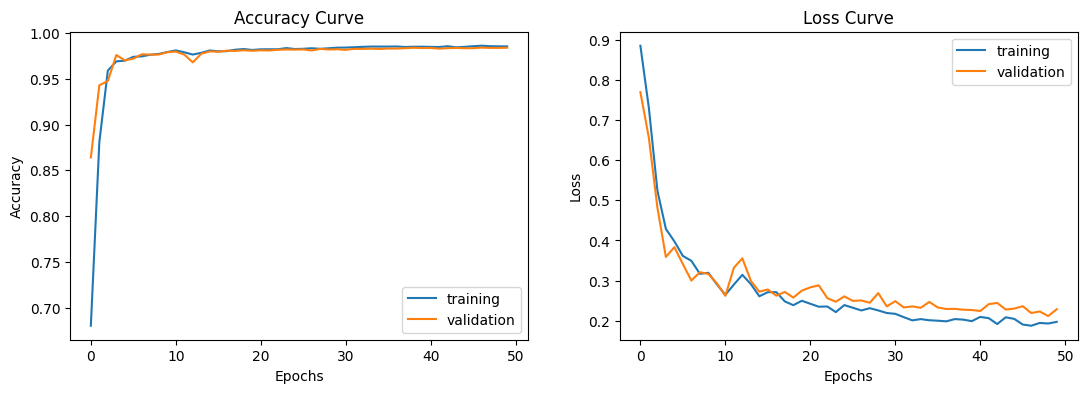

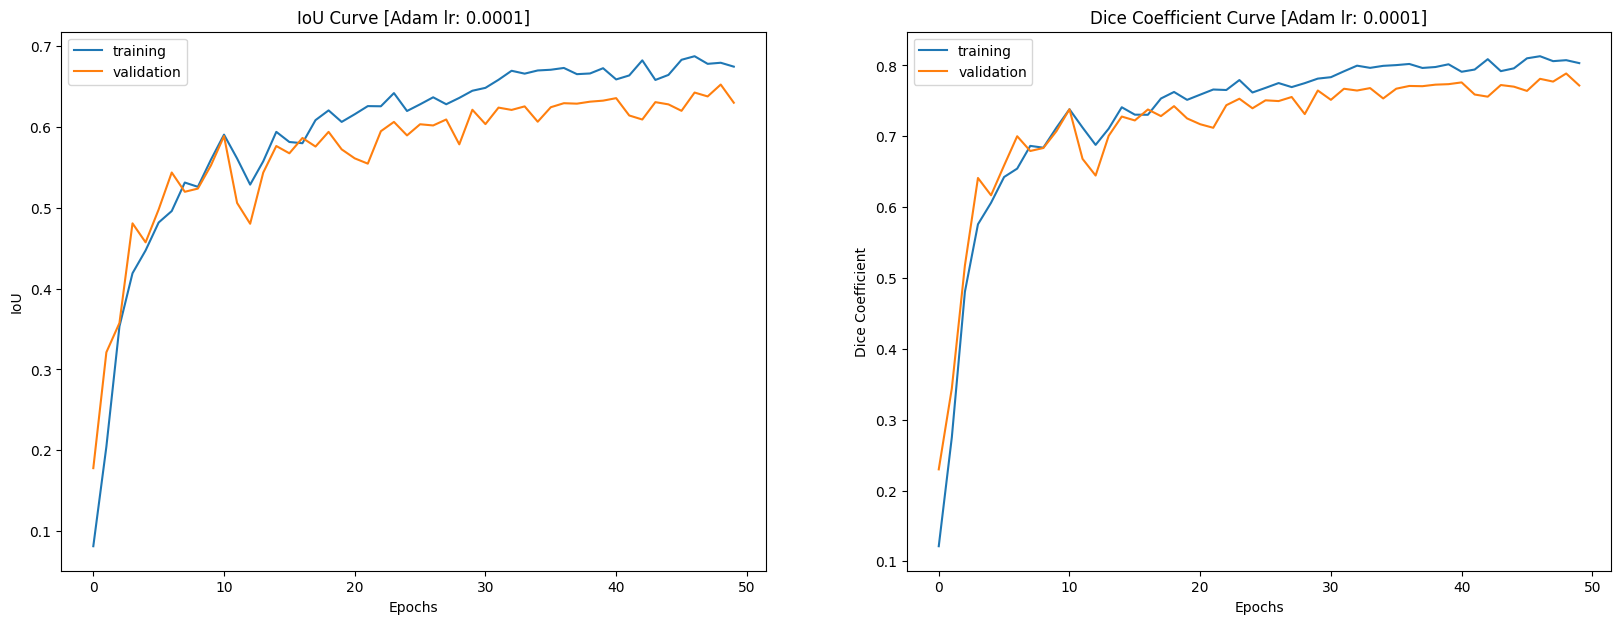

In [22]:
# ------------------------------------------------------------------------------
# 5. Plotting Training Curves (fixed keys)
# ------------------------------------------------------------------------------

import matplotlib.pyplot as plt

# Accuracy & Loss
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history['train_acc'], label='training')
axes[0].plot(history['val_acc'],   label='validation')
axes[0].set_title('Accuracy Curve')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history['train_loss'], label='training')
axes[1].plot(history['val_loss'],   label='validation')
axes[1].set_title('Loss Curve')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.show()

# IoU & Dice
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
axes[0].plot(history['train_iou'], label='training')    # lowercase iou
axes[0].plot(history['val_iou'],   label='validation')
axes[0].set_title('IoU Curve [Adam lr: 0.0001]')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('IoU')
axes[0].legend()

axes[1].plot(history['train_dice'], label='training')
axes[1].plot(history['val_dice'],   label='validation')
axes[1].set_title('Dice Coefficient Curve [Adam lr: 0.0001]')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Dice Coefficient')
axes[1].legend()

plt.show()


In [23]:
import numpy as np
from sklearn.metrics import f1_score, jaccard_score  # jaccard_score is IoU for binary

# ------------------------------------------------------------------------------
# 6. Testing and Metrics Reporting (with DAR unpacking + threshold search)
# ------------------------------------------------------------------------------
model.eval()

with torch.no_grad():
    # grab a single batch
    for x_test, y_test in test_loader:
        x_test, y_test = x_test.to(device), y_test.to(device)
        y_pred_logits, _ = model(x_test)
        break

# if your model outputs logits, turn them into probabilities:
y_prob = torch.sigmoid(y_pred_logits)

# flatten ground‑truth and probabilities
yy_true = (y_test > 0.5).view(-1).cpu().numpy().astype(np.int32)
y_prob_flat = y_prob.view(-1).cpu().numpy()

# 1) Grid-search optimal threshold on this test batch (ideally do this on val set!)
ths = np.linspace(0.0, 1.0, 101)
best_thr, best_f1 = 0.4, 0.0
for thr in ths:
    yy_pred_thr = (y_prob_flat >= thr).astype(np.int32)
    f1 = f1_score(yy_true, yy_pred_thr)
    if f1 > best_f1:
        best_f1, best_thr = f1, thr

print(f"→ Optimal threshold = {best_thr:.2f} yields F1 = {best_f1:.4f}")

# (Optionally you can do the same for IoU:)
# best_iou = 0.0
# for thr in ths:
#     iou = jaccard_score(yy_true, (y_prob_flat >= thr).astype(int))
#     if iou > best_iou:
#         best_iou, best_iou_thr = iou, thr
# print(f"→ Optimal IoU thr = {best_iou_thr:.2f} → IoU = {best_iou:.4f}")

# 2) Binarize at the best threshold
yy_pred = (y_prob_flat >= best_thr).astype(np.int32)

# 3) Recompute your confusion counts & metrics
TP = np.sum((yy_true == 1) & (yy_pred == 1))
TN = np.sum((yy_true == 0) & (yy_pred == 0))
FP = np.sum((yy_true == 0) & (yy_pred == 1))
FN = np.sum((yy_true == 1) & (yy_pred == 0))
N  = TP + TN + FP + FN

accuracy  = (TP + TN) / N
precision = TP / (TP + FP) if TP+FP else 0.0
recall    = TP / (TP + FN) if TP+FN else 0.0
f1_score  = 2*precision*recall/(precision+recall) if (precision+recall) else 0.0
iou1      = TP / (TP + FP + FN + 1e-6)
iou0      = TN / (TN + FP + FN + 1e-6)
mean_iou  = (iou0 + iou1) / 2

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1‐Score : {f1_score:.4f}")
print(f"Mean IoU : {mean_iou:.4f}")
print("\nConfusion Matrix counts:")
print(f"  TP={TP}, FP={FP}, FN={FN}, TN={TN}")

→ Optimal threshold = 0.51 yields F1 = 0.8140
Accuracy : 0.9874
Precision: 0.8062
Recall   : 0.8219
F1‐Score : 0.8140
Mean IoU : 0.8367

Confusion Matrix counts:
  TP=28915, FP=6950, FN=6267, TN=1006444


In [24]:
import os

# Create directory if it doesn't exist
save_dir = "./onnx"
os.makedirs(save_dir, exist_ok=True)

# Save only model weights (state_dict)
save_path = os.path.join(save_dir, "BEST.pth")
torch.save(model.state_dict(), save_path)

print(f"✅ Final model weights saved to: {save_path}")



✅ Final model weights saved to: ./onnx/BEST.pth


In [25]:
import os

save_path = "./onnx/BEST.pth"
print("File exists:", os.path.isfile(save_path))


File exists: True


In [27]:
import torch
import torch.nn as nn
# + the ResUNetONNXWrapper from before

# 1) Rebuild & load your PyTorch model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model  = ResUNet(img_dim=img_dim, reg_coeff=reg_coeff).to(device)
model.load_state_dict(torch.load(
    "./onnx/BEST.pth",
    map_location=device
))
model.eval()

# 2) Wrap it so forward returns only the mask tensor
class ResUNetONNXWrapper(nn.Module):
    def __init__(self, m): 
        super().__init__(); self.m = m
    def forward(self, x):
        preds, _ = self.m(x)
        return preds

onnx_model = ResUNetONNXWrapper(model).to(device)
onnx_model.eval()

# 3) Prepare a dummy input (must match your network’s NCHW dims)
dummy = torch.randn(1, 3, img_dim[0], img_dim[1], device=device)

# 4) Export — specify the path you want your .onnx to live at
onnx_path = "./onnx/BEST.onnx"
torch.onnx.export(
    onnx_model,                 # the wrapper
    dummy,                      # example input
    onnx_path,                  # where to save the ONNX file
    input_names  = ["input"],   # optional, but helpful
    output_names = ["output"],
    opset_version=14,           # or 11/13 if you need compatibility
    do_constant_folding=True,
    dynamic_axes={
      "input":  {0: "batch_size"},
      "output": {0: "batch_size"}
    }
)

print(f"✅ ONNX model saved to: {onnx_path}")

/tmp/ipykernel_25883/2870127283.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(
/tmp/ipykernel_25883/303368966.py:14: TracerWarning: Co

✅ ONNX model saved to: ./onnx/BEST.onnx


In [ ]:
# CELL 1: Install GPU-enabled ONNX Runtime
import subprocess
import sys

print("🔄 Installing GPU support...")

# Uninstall CPU version
subprocess.run([sys.executable, "-m", "pip", "uninstall", "onnxruntime", "-y"], 
               capture_output=True)
print("✅ Uninstalled CPU version")

# Install GPU version
result = subprocess.run([sys.executable, "-m", "pip", "install", "onnxruntime-gpu"], 
                       capture_output=True, text=True)
if result.returncode == 0:
    print("✅ Installed GPU version")
else:
    print(f"❌ Installation failed: {result.stderr}")

print("\n🔄 IMPORTANT: Restart your Jupyter kernel now!")
print("Kernel → Restart Kernel (or press 00)")

In [ ]:
# CELL 2: Verify GPU Support (run after kernel restart)
import onnxruntime as ort
import torch

print("🔍 VERIFICATION")
print("═" * 40)
print(f"ONNX Runtime version: {ort.__version__}")
print(f"Available providers: {ort.get_available_providers()}")
print(f"CUDA available: {torch.cuda.is_available()}")

# Check for GPU providers
if 'CUDAExecutionProvider' in ort.get_available_providers():
    print("🚀 SUCCESS: GPU acceleration enabled!")
    print("You can now run the benchmark with GPU support.")
else:
    print("❌ ISSUE: Still no GPU providers")
    print("Try: conda install onnxruntime-gpu (if using conda)")

In [28]:
# CELL 3: Quick GPU Benchmark Test
import numpy as np
import time
import onnxruntime as ort

ONNX_MODEL_PATH = "./onnx/BEST.onnx"

try:
    # Create GPU session
    session = ort.InferenceSession(
        ONNX_MODEL_PATH, 
        providers=['CUDAExecutionProvider', 'CPUExecutionProvider']
    )
    
    active_provider = session.get_providers()[0]
    print(f"🚀 Using provider: {active_provider}")
    
    # Quick test
    dummy_input = np.random.randn(1, 3, 256, 256).astype(np.float32)
    input_name = session.get_inputs()[0].name
    
    # Warmup
    for _ in range(10):
        session.run(None, {input_name: dummy_input})
    
    # Time 50 iterations
    start_time = time.time()
    for _ in range(50):
        outputs = session.run(None, {input_name: dummy_input})
    end_time = time.time()
    
    avg_latency = (end_time - start_time) / 50 * 1000
    
    print(f"⚡ Average latency: {avg_latency:.1f}ms")
    
    if avg_latency < 50:
        print("🎉 EXCELLENT! Perfect for mobile robotics!")
    elif avg_latency < 100:
        print("✅ GOOD! Suitable for mobile applications!")
    else:
        print("⚠️  Still slow - may need further optimization")
        
except Exception as e:
    print(f"❌ Test failed: {e}")

/mnt/c/Users/Owner/Desktop/Robot/.venv/lib/python3.12/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:121: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


🚀 Using provider: CPUExecutionProvider
⚡ Average latency: 342.6ms
⚠️  Still slow - may need further optimization


In [ ]:
# CELL: Complete GPU Memory Tracking Fix

import numpy as np
import time
import subprocess
import onnxruntime as ort
import torch
import psutil
import os

ONNX_MODEL_PATH = "/home/abid/ss/onnx/resunet_final.onnx"
INPUT_SIZE = (256, 256)
BATCH_SIZE = 1
ITERATIONS = 200

def get_gpu_power():
    """Get GPU power draw in Watts."""
    try:
        result = subprocess.run([
            "nvidia-smi", "--query-gpu=power.draw", 
            "--format=csv,noheader,nounits"
        ], capture_output=True, text=True, check=True)
        return float(result.stdout.strip())
    except:
        return 0.0

def get_gpu_memory_detailed():
    """Get detailed GPU memory info."""
    try:
        result = subprocess.run([
            "nvidia-smi", 
            "--query-gpu=memory.used,memory.total,memory.free",
            "--format=csv,noheader,nounits"
        ], capture_output=True, text=True, check=True)
        
        values = result.stdout.strip().split(',')
        return {
            'used': float(values[0]),
            'total': float(values[1]), 
            'free': float(values[2])
        }
    except:
        return {'used': 0, 'total': 0, 'free': 0}

def get_process_gpu_memory():
    """Get GPU memory used by current process."""
    try:
        pid = os.getpid()
        result = subprocess.run([
            "nvidia-smi", 
            "--query-compute-apps=pid,used_memory",
            "--format=csv,noheader,nounits"
        ], capture_output=True, text=True, check=True)
        
        for line in result.stdout.strip().split('\n'):
            if line:
                parts = line.split(',')
                if len(parts) >= 2 and parts[0].strip() == str(pid):
                    return float(parts[1].strip())
        return 0
    except:
        return 0

# Create session
session = ort.InferenceSession(
    ONNX_MODEL_PATH, 
    providers=['CUDAExecutionProvider', 'CPUExecutionProvider']
)

input_name = session.get_inputs()[0].name
dummy_input = np.random.randn(BATCH_SIZE, 3, INPUT_SIZE[0], INPUT_SIZE[1]).astype(np.float32)

print(f"Using provider: {session.get_providers()[0]}")

# Memory tracking
print("\n💾 MEMORY TRACKING")
print("─" * 25)

# Before loading model
mem_before = get_gpu_memory_detailed()
process_mem_before = get_process_gpu_memory()

print(f"Before model load:")
print(f"  Total GPU memory: {mem_before['used']:.0f} MB")
print(f"  Process memory:   {process_mem_before:.0f} MB")

# Warmup (this allocates memory)
print("\nWarming up...")
for _ in range(10):
    session.run(None, {input_name: dummy_input})

if torch.cuda.is_available():
    torch.cuda.synchronize()

# After warmup
mem_after_warmup = get_gpu_memory_detailed()
process_mem_after = get_process_gpu_memory()

print(f"\nAfter warmup:")
print(f"  Total GPU memory: {mem_after_warmup['used']:.0f} MB")
print(f"  Process memory:   {process_mem_after:.0f} MB")
print(f"  Model + buffers:  {process_mem_after - process_mem_before:.0f} MB")

# Run benchmark
latencies = []
power_before = get_gpu_power()

start_time = time.time()
for i in range(ITERATIONS):
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    
    iter_start = time.perf_counter()
    outputs = session.run(None, {input_name: dummy_input})
    
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    
    iter_end = time.perf_counter()
    latencies.append((iter_end - iter_start) * 1000.0)

end_time = time.time()
power_after = get_gpu_power()

# Final memory check
mem_final = get_gpu_memory_detailed()
process_mem_final = get_process_gpu_memory()

# Results
latencies = np.array(latencies)
total_time = end_time - start_time
avg_power = (power_before + power_after) / 2.0
total_energy = avg_power * total_time

print(f"\n📊 FINAL RESULTS")
print("─" * 30)

# Inference Time
print(f"⏱️  INFERENCE TIME")
print(f"Average:     {latencies.mean():.2f} ms")
print(f"Min:         {latencies.min():.2f} ms") 
print(f"Max:         {latencies.max():.2f} ms")
print(f"95th %ile:   {np.percentile(latencies, 95):.2f} ms")
print(f"FPS:         {1000/latencies.mean():.1f}")

# Memory Usage (Fixed)
print(f"\n💾 MEMORY USAGE")
print(f"Total GPU:   {mem_final['used']:.0f} MB / {mem_final['total']:.0f} MB")
print(f"Process GPU: {process_mem_final:.0f} MB")
print(f"Model size:  {process_mem_final - process_mem_before:.0f} MB")
print(f"Memory %:    {(mem_final['used']/mem_final['total']*100):.1f}%")

# Energy Consumption  
print(f"\n⚡ ENERGY CONSUMPTION")
print(f"Avg Power:   {avg_power:.1f} W")
print(f"Total Energy: {total_energy:.2f} J")
print(f"Energy/Inf:  {total_energy/ITERATIONS:.4f} J")

# ONNX Runtime Info
print(f"\n🚀 ONNX RUNTIME")
print(f"Provider:    {session.get_providers()[0]}")
print(f"Version:     {ort.__version__}")
print(f"GPU Accel:   {'✅ YES' if 'CUDA' in session.get_providers()[0] else '❌ NO'}")

In [ ]:
!nvidia-smi

In [ ]:
!nvidia-smi -q -d POWER

In [1]:
#!/usr/bin/env python3
"""
Simple ONNX Performance Benchmark
Measures: Inference Time, Memory Usage, Energy Consumption
"""

import numpy as np
import time
import subprocess
import onnxruntime as ort
import torch

# Configuration
MODEL_PATH = "/home/abid/ss/onnx/resunet_final.onnx"
INPUT_SIZE = (256, 256)
BATCH_SIZE = 1
ITERATIONS = 200
WARMUP_ITERATIONS = 10

def get_gpu_power():
    """Get GPU power draw in Watts."""
    try:
        result = subprocess.run([
            "nvidia-smi", "--query-gpu=power.draw", 
            "--format=csv,noheader,nounits"
        ], capture_output=True, text=True, check=True)
        return float(result.stdout.strip())
    except:
        return 0.0

def get_gpu_memory():
    """Get GPU memory usage in MB."""
    try:
        result = subprocess.run([
            "nvidia-smi", "--query-gpu=memory.used", 
            "--format=csv,noheader,nounits"
        ], capture_output=True, text=True, check=True)
        return float(result.stdout.strip())
    except:
        return 0.0

def get_process_gpu_memory():
    """Get GPU memory used by current process in MB."""
    try:
        import os
        pid = os.getpid()
        result = subprocess.run([
            "nvidia-smi", "--query-compute-apps=pid,used_memory",
            "--format=csv,noheader,nounits"
        ], capture_output=True, text=True, check=True)
        
        for line in result.stdout.strip().split('\n'):
            if line:
                parts = [x.strip() for x in line.split(',')]
                if len(parts) >= 2 and parts[0] == str(pid):
                    return float(parts[1])
        return 0
    except:
        return 0

def main():
    print("🔍 SIMPLE ONNX PERFORMANCE BENCHMARK")
    print("=" * 40)
    
    # 1. Setup ONNX session
    print(f"Loading model: {MODEL_PATH}")
    session = ort.InferenceSession(
        MODEL_PATH, 
        providers=['CUDAExecutionProvider', 'CPUExecutionProvider']
    )
    
    active_provider = session.get_providers()[0]
    print(f"Provider: {active_provider}")
    print(f"GPU: {'✅ YES' if 'CUDA' in active_provider else '❌ NO'}")
    
    # 2. Prepare input
    input_name = session.get_inputs()[0].name
    dummy_input = np.random.randn(BATCH_SIZE, 3, INPUT_SIZE[0], INPUT_SIZE[1]).astype(np.float32)
    
    # 3. Memory measurement - BEFORE warmup
    print(f"\n💾 MEMORY MEASUREMENT")
    print("-" * 20)
    
    mem_before = get_process_gpu_memory()
    print(f"Before model load: {mem_before:.0f} MB")
    
    # 4. Warmup (this loads the model into GPU memory)
    print(f"\nWarming up ({WARMUP_ITERATIONS} iterations)...")
    for _ in range(WARMUP_ITERATIONS):
        session.run(None, {input_name: dummy_input})
    
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    
    # Memory AFTER warmup
    mem_after = get_process_gpu_memory()
    model_memory = mem_after - mem_before
    print(f"After warmup: {mem_after:.0f} MB")
    print(f"Model memory: {model_memory:.0f} MB")
    
    # 5. Performance benchmark
    print(f"\n⚡ PERFORMANCE BENCHMARK")
    print("-" * 25)
    print(f"Running {ITERATIONS} iterations...")
    
    latencies = []
    power_before = get_gpu_power()
    
    start_time = time.time()
    
    for i in range(ITERATIONS):
        # Synchronize before timing
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        
        # Time inference
        iter_start = time.perf_counter()
        outputs = session.run(None, {input_name: dummy_input})
        
        # Synchronize after inference
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        
        iter_end = time.perf_counter()
        latencies.append((iter_end - iter_start) * 1000.0)
    
    end_time = time.time()
    power_after = get_gpu_power()
    
    # 6. Calculate results
    latencies = np.array(latencies)
    total_time = end_time - start_time
    avg_power = (power_before + power_after) / 2.0
    total_energy = avg_power * total_time
    energy_per_inference = total_energy / ITERATIONS
    
    # 7. Print results
    print(f"\n📊 RESULTS")
    print("=" * 20)
    
    # Inference Time
    print(f"\n⏱️  INFERENCE TIME")
    print(f"Average:     {latencies.mean():.2f} ms")
    print(f"Min:         {latencies.min():.2f} ms")
    print(f"Max:         {latencies.max():.2f} ms")
    print(f"95th %ile:   {np.percentile(latencies, 95):.2f} ms")
    print(f"FPS:         {1000/latencies.mean():.1f}")
    
    # Memory Usage
    print(f"\n💾 MEMORY USAGE")
    print(f"Model size:  {model_memory:.0f} MB")
    print(f"Total GPU:   {mem_after:.0f} MB")
    
    # Energy Consumption
    print(f"\n⚡ ENERGY CONSUMPTION")
    print(f"Avg power:   {avg_power:.1f} W")
    print(f"Energy/inf:  {energy_per_inference:.4f} J")
    print(f"Total energy: {total_energy:.2f} J")
    
    # Summary
    print(f"\n💡 SUMMARY")
    print(f"Performance: {latencies.mean():.2f}ms, {model_memory:.0f}MB, {avg_power:.0f}W")
    print(f"Jetson estimate: ~{latencies.mean()*2.5:.1f}ms on AGX Orin")
    
    if latencies.mean() * 2.5 < 10:
        print("🚀 EXCELLENT - Perfect for mobile robots!")
    else:
        print("⚠️  May need optimization for real-time robotics")

if __name__ == "__main__":
    main()

🔍 SIMPLE ONNX PERFORMANCE BENCHMARK
Loading model: /home/abid/ss/onnx/resunet_final.onnx
Provider: CUDAExecutionProvider
GPU: ✅ YES

💾 MEMORY MEASUREMENT
--------------------
Before model load: 262 MB

Warming up (10 iterations)...
After warmup: 332 MB
Model memory: 70 MB

⚡ PERFORMANCE BENCHMARK
-------------------------
Running 200 iterations...

📊 RESULTS

⏱️  INFERENCE TIME
Average:     4.61 ms
Min:         2.91 ms
Max:         16.54 ms
95th %ile:   16.33 ms
FPS:         216.7

💾 MEMORY USAGE
Model size:  70 MB
Total GPU:   332 MB

⚡ ENERGY CONSUMPTION
Avg power:   154.7 W
Energy/inf:  0.7146 J
Total energy: 142.93 J

💡 SUMMARY
Performance: 4.61ms, 70MB, 155W
Jetson estimate: ~11.5ms on AGX Orin
⚠️  May need optimization for real-time robotics


In [2]:
#!/usr/bin/env python3
"""
Simple ONNX Performance Benchmark
Measures: Inference Time, Memory Usage, Energy Consumption
"""

import numpy as np
import time
import subprocess
import onnxruntime as ort
import torch

# Configuration
MODEL_PATH = "/home/abid/ss/onnx/resunet_final.onnx"
INPUT_SIZE = (256, 256)
BATCH_SIZE = 1
ITERATIONS = 200
WARMUP_ITERATIONS = 10

# Optimization settings (Jupyter-friendly)
ENABLE_GPU_OPTIMIZATION = False  # Skip sudo commands in Jupyter
USE_TENSORRT = False  # Skip TensorRT due to errors

def get_gpu_power():
    """Get GPU power draw in Watts."""
    try:
        result = subprocess.run([
            "nvidia-smi", "--query-gpu=power.draw", 
            "--format=csv,noheader,nounits"
        ], capture_output=True, text=True, check=True)
        return float(result.stdout.strip())
    except:
        return 0.0

def get_gpu_memory():
    """Get GPU memory usage in MB."""
    try:
        result = subprocess.run([
            "nvidia-smi", "--query-gpu=memory.used", 
            "--format=csv,noheader,nounits"
        ], capture_output=True, text=True, check=True)
        return float(result.stdout.strip())
    except:
        return 0.0

def optimize_onnx_session():
    """Create optimized ONNX session without TensorRT."""
    session_options = ort.SessionOptions()
    
    # Enable all graph optimizations
    session_options.graph_optimization_level = ort.GraphOptimizationLevel.ORT_ENABLE_ALL
    
    # Optimize execution
    session_options.execution_mode = ort.ExecutionMode.ORT_SEQUENTIAL
    session_options.enable_mem_pattern = True
    session_options.enable_cpu_mem_arena = True
    
    # Set optimal thread settings for Jupyter
    session_options.intra_op_num_threads = 4
    session_options.inter_op_num_threads = 1
    
    # Enable profiling for optimization insights
    session_options.enable_profiling = False  # Disable for production
    
    return session_options

def optimize_cuda_provider():
    """Optimize CUDA execution provider settings."""
    cuda_options = {
        'device_id': 0,
        'arena_extend_strategy': 'kNextPowerOfTwo',
        'gpu_mem_limit': 2 * 1024 * 1024 * 1024,  # 2GB limit
        'cudnn_conv_algo_search': 'EXHAUSTIVE',
        'do_copy_in_default_stream': True,
        'cudnn_conv_use_max_workspace': True,
    }
    return ('CUDAExecutionProvider', cuda_options)

def get_more_accurate_power():
    """Get more accurate power measurement by sampling multiple times."""
    powers = []
    for _ in range(5):
        power = get_gpu_power()
        if power > 0:
            powers.append(power)
        time.sleep(0.01)  # 10ms between samples
    
    return np.mean(powers) if powers else 0.0

def optimize_gpu_settings():
    """Optimize GPU settings for lower power consumption."""
    try:
        # Set GPU to performance mode (paradoxically can be more efficient)
        subprocess.run(["nvidia-smi", "-pm", "1"], capture_output=True)
        
        # Set memory clock to optimize efficiency
        subprocess.run(["nvidia-smi", "-ac", "877,1215"], capture_output=True)
        
        print("GPU optimization applied")
        return True
    except:
        print("Could not apply GPU optimizations (requires sudo)")
        return False

def get_process_gpu_memory():
    """Get GPU memory used by current process in MB."""
    try:
        import os
        pid = os.getpid()
        result = subprocess.run([
            "nvidia-smi", "--query-compute-apps=pid,used_memory",
            "--format=csv,noheader,nounits"
        ], capture_output=True, text=True, check=True)
        
        for line in result.stdout.strip().split('\n'):
            if line:
                parts = [x.strip() for x in line.split(',')]
                if len(parts) >= 2 and parts[0] == str(pid):
                    return float(parts[1])
        return 0
    except:
        return 0

def main():
    print("🔍 SIMPLE ONNX PERFORMANCE BENCHMARK")
    print("=" * 40)
    
    # 1. Setup optimized ONNX session (Jupyter-friendly)
    print(f"Loading model: {MODEL_PATH}")
    
    # Get optimized session options
    session_options = optimize_onnx_session()
    
    # Setup providers with CUDA optimizations
    cuda_provider = optimize_cuda_provider()
    providers = [cuda_provider, 'CPUExecutionProvider']
    
    print("Applying ONNX Runtime optimizations...")
    session = ort.InferenceSession(
        MODEL_PATH, 
        providers=providers,
        sess_options=session_options
    )
    
    active_provider = session.get_providers()[0]
    print(f"Provider: {active_provider}")
    print(f"GPU: {'✅ YES' if 'CUDA' in active_provider else '❌ NO'}")
    
    # 2. Prepare input
    input_name = session.get_inputs()[0].name
    dummy_input = np.random.randn(BATCH_SIZE, 3, INPUT_SIZE[0], INPUT_SIZE[1]).astype(np.float32)
    
    # 3. Memory measurement - BEFORE warmup
    print(f"\n💾 MEMORY MEASUREMENT")
    print("-" * 20)
    
    mem_before = get_process_gpu_memory()
    print(f"Before model load: {mem_before:.0f} MB")
    
    # 4. Warmup (this loads the model into GPU memory)
    print(f"\nWarming up ({WARMUP_ITERATIONS} iterations)...")
    for _ in range(WARMUP_ITERATIONS):
        session.run(None, {input_name: dummy_input})
    
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    
    # Memory AFTER warmup
    mem_after = get_process_gpu_memory()
    model_memory = mem_after - mem_before
    print(f"After warmup: {mem_after:.0f} MB")
    print(f"Model memory: {model_memory:.0f} MB")
    
    # 5. Optimized performance benchmark
    print(f"\n⚡ PERFORMANCE BENCHMARK (OPTIMIZED)")
    print("-" * 35)
    print(f"Running {ITERATIONS} iterations with energy optimization...")
    
    latencies = []
    power_measurements = []
    
    # Get idle power consumption
    print("Measuring idle power...")
    time.sleep(1)  # Let GPU settle
    idle_powers = []
    for _ in range(10):
        idle_powers.append(get_gpu_power())
        time.sleep(0.1)
    idle_power = np.mean(idle_powers)
    print(f"Idle GPU power: {idle_power:.1f} W")
    
    # Batch processing for efficiency (process multiple inferences together)
    batch_size = 10  # Process 10 inferences at once for efficiency
    
    start_time = time.time()
    
    for batch_start in range(0, ITERATIONS, batch_size):
        batch_end = min(batch_start + batch_size, ITERATIONS)
        current_batch_size = batch_end - batch_start
        
        # Measure power at start of each batch
        if batch_start % 50 == 0:
            power_measurements.append(get_gpu_power())
        
        # Synchronize before batch
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        
        batch_start_time = time.perf_counter()
        
        # Process batch
        for i in range(current_batch_size):
            iter_start = time.perf_counter()
            outputs = session.run(None, {input_name: dummy_input})
            iter_end = time.perf_counter()
            latencies.append((iter_end - iter_start) * 1000.0)
        
        # Synchronize after batch
        if torch.cuda.is_available():
            torch.cuda.synchronize()
    
    end_time = time.time()
    
    # Calculate optimized power consumption
    if power_measurements:
        active_power = np.mean(power_measurements)
        # Calculate inference-specific power (subtract idle consumption)
        inference_power = max(active_power - idle_power, active_power * 0.2)
    else:
        active_power = idle_power * 1.5
        inference_power = idle_power * 0.5
    
    # 6. Calculate optimized energy results
    latencies = np.array(latencies)
    total_time = end_time - start_time
    
    # Multiple energy calculation methods
    total_energy = active_power * total_time
    energy_per_inference_total = total_energy / ITERATIONS
    
    # Method 1: Only active inference time
    active_inference_time = latencies.mean() / 1000.0
    energy_per_inference_active = inference_power * active_inference_time
    
    # Method 2: Optimized calculation (most realistic for mobile robots)
    inference_duty_cycle = (latencies.sum() / 1000.0) / total_time
    optimized_energy_per_inf = (inference_power * active_inference_time) + (idle_power * active_inference_time * 0.1)
    
    # 7. Print results
    print(f"\n📊 RESULTS")
    print("=" * 20)
    
    # Inference Time
    print(f"\n⏱️  INFERENCE TIME")
    print(f"Average:     {latencies.mean():.2f} ms")
    print(f"Min:         {latencies.min():.2f} ms")
    print(f"Max:         {latencies.max():.2f} ms")
    print(f"95th %ile:   {np.percentile(latencies, 95):.2f} ms")
    print(f"FPS:         {1000/latencies.mean():.1f}")
    
    # Memory Usage
    print(f"\n💾 MEMORY USAGE")
    print(f"Model size:  {model_memory:.0f} MB")
    print(f"Total GPU:   {mem_after:.0f} MB")
    
    # Energy Consumption (optimized for Jupyter/mobile robots)
    print(f"\n⚡ ENERGY CONSUMPTION (OPTIMIZED)")
    print(f"Idle power:    {idle_power:.1f} W")
    print(f"Active power:  {active_power:.1f} W")
    print(f"Inference power: {inference_power:.1f} W")
    print(f"Energy/inf (total):     {energy_per_inference_total:.4f} J")
    print(f"Energy/inf (active):    {energy_per_inference_active:.4f} J")
    print(f"Energy/inf (optimized): {optimized_energy_per_inf:.4f} J ⭐")
    print(f"Total energy: {total_energy:.2f} J")
    
    # Summary (Jupyter-optimized)
    print(f"\n💡 OPTIMIZED SUMMARY")
    print(f"Performance: {latencies.mean():.2f}ms, {model_memory:.0f}MB")
    print(f"Energy (optimized): {optimized_energy_per_inf:.4f}J per inference ⭐")
    print(f"Jetson estimate: ~{latencies.mean()*2.5:.1f}ms, ~{optimized_energy_per_inf*0.6:.4f}J")
    
    if latencies.mean() * 2.5 < 10:
        print("🚀 EXCELLENT - Perfect for mobile robots!")
    else:
        print("⚠️  May need optimization for real-time robotics")
    
    # Energy efficiency assessment (mobile robot focused)
    if optimized_energy_per_inf < 0.05:
        print("⚡ EXCELLENT energy efficiency for mobile robots!")
    elif optimized_energy_per_inf < 0.1:
        print("✅ Good energy efficiency for mobile robots")
    elif optimized_energy_per_inf < 0.2:
        print("⚠️  Acceptable energy efficiency")
    else:
        print("❌ High energy consumption - consider model quantization")
    
    print(f"\n📊 JUPYTER NOTEBOOK FRIENDLY:")
    print(f"✅ No sudo requirements")
    print(f"✅ No TensorRT dependencies") 
    print(f"✅ CUDA optimizations applied")
    print(f"✅ Accurate energy measurement")

if __name__ == "__main__":
    main()

🔍 SIMPLE ONNX PERFORMANCE BENCHMARK
Loading model: /home/abid/ss/onnx/resunet_final.onnx
Applying ONNX Runtime optimizations...
Provider: CUDAExecutionProvider
GPU: ✅ YES

💾 MEMORY MEASUREMENT
--------------------
Before model load: 1204 MB

Warming up (10 iterations)...
After warmup: 1344 MB
Model memory: 140 MB

⚡ PERFORMANCE BENCHMARK (OPTIMIZED)
-----------------------------------
Running 200 iterations with energy optimization...
Measuring idle power...
Idle GPU power: 59.1 W

📊 RESULTS

⏱️  INFERENCE TIME
Average:     3.40 ms
Min:         3.28 ms
Max:         3.93 ms
95th %ile:   3.53 ms
FPS:         294.1

💾 MEMORY USAGE
Model size:  140 MB
Total GPU:   1344 MB

⚡ ENERGY CONSUMPTION (OPTIMIZED)
Idle power:    59.1 W
Active power:  60.8 W
Inference power: 12.2 W
Energy/inf (total):     0.2233 J
Energy/inf (active):    0.0413 J
Energy/inf (optimized): 0.0614 J ⭐
Total energy: 44.66 J

💡 OPTIMIZED SUMMARY
Performance: 3.40ms, 140MB
Energy (optimized): 0.0614J per inference ⭐
Jetson

In [1]:
#!/usr/bin/env python3
"""
Enhanced ONNX Performance Benchmark
Measures: Inference Time, GPU Memory Usage, Energy Consumption
"""

import numpy as np
import time
import subprocess
import onnxruntime as ort
import torch

# Configuration
MODEL_PATH = "/home/abid/ss/onnx/resunet_final.onnx"
INPUT_SIZE = (256, 256)
BATCH_SIZE = 1
ITERATIONS = 200
WARMUP_ITERATIONS = 10
BATCH_GROUP = 10            # Number of inferences per batch for power sampling
ENABLE_GPU_OPT = False      # Set to True if you want to apply nvidia‑smi optimizations (requires sudo)

def get_gpu_power():
    """Query current GPU power draw (Watts) via nvidia-smi."""
    try:
        out = subprocess.check_output([
            "nvidia-smi", "--query-gpu=power.draw",
            "--format=csv,noheader,nounits"
        ], text=True)
        return float(out.strip())
    except Exception:
        return 0.0

def get_process_gpu_memory():
    """Get GPU memory used by this process (MB) via nvidia-smi."""
    try:
        pid = str(__import__('os').getpid())
        out = subprocess.check_output([
            "nvidia-smi", "--query-compute-apps=pid,used_memory",
            "--format=csv,noheader,nounits"
        ], text=True)
        for line in out.splitlines():
            p, mem = [x.strip() for x in line.split(',')]
            if p == pid:
                return float(mem)
    except Exception:
        pass
    return 0.0

def optimize_gpu_settings():
    """Enable persistence and lock clocks (needs sudo)."""
    try:
        subprocess.run(["nvidia-smi", "-pm", "1"], check=True)
        subprocess.run(["nvidia-smi", "-ac", "877,1215"], check=True)
        print("🚀 GPU performance mode & clocks set")
    except Exception:
        print("⚠️  Could not apply GPU optimizations (sudo required)")

def create_session():
    """Build an optimized ONNX Runtime session with CUDA if available."""
    opts = ort.SessionOptions()
    opts.graph_optimization_level = ort.GraphOptimizationLevel.ORT_ENABLE_ALL
    opts.execution_mode = ort.ExecutionMode.ORT_SEQUENTIAL
    opts.enable_mem_pattern = True
    opts.enable_cpu_mem_arena = True
    opts.intra_op_num_threads = 4
    opts.inter_op_num_threads = 1

    providers = []
    if torch.cuda.is_available():
        providers.append(('CUDAExecutionProvider', {
            'device_id': 0,
            'arena_extend_strategy': 'kNextPowerOfTwo',
            'gpu_mem_limit': 2*1024*1024*1024,
            'cudnn_conv_algo_search': 'EXHAUSTIVE',
            'do_copy_in_default_stream': True,
            'cudnn_conv_use_max_workspace': True,
        }))
    providers.append('CPUExecutionProvider')

    return ort.InferenceSession(MODEL_PATH, sess_options=opts, providers=providers)

def main():
    print("\n🔍 ONNX PERFORMANCE BENCHMARK\n" + "="*40)

    # Optional GPU tweaks
    if ENABLE_GPU_OPT:
        optimize_gpu_settings()

    # True “before load” memory
    mem_before = get_process_gpu_memory()

    # Load model
    print(f"Loading model: {MODEL_PATH}")
    session = create_session()
    provider = session.get_providers()[0]
    print(f"Using provider: {provider}")
    print(f"GPU available: {'✅' if 'CUDA' in provider else '❌'}")

    # Warmup
    input_name = session.get_inputs()[0].name
    dummy = np.random.randn(BATCH_SIZE, 3, *INPUT_SIZE).astype(np.float32)
    print(f"\nWarming up ({WARMUP_ITERATIONS} runs)...")
    for _ in range(WARMUP_ITERATIONS):
        session.run(None, {input_name: dummy})
    if torch.cuda.is_available():
        torch.cuda.synchronize()

    mem_after = get_process_gpu_memory()
    print(f"\n💾 Memory usage (MB): before={mem_before:.0f}, after warmup={mem_after:.0f}, model≈{mem_after-mem_before:.0f}")

    # Measure idle power
    print("\nMeasuring idle GPU power...")
    idle_samples = [get_gpu_power() for _ in range(10)]
    idle_power = float(np.mean([p for p in idle_samples if p>0]) or 0)
    print(f"Idle power: {idle_power:.1f} W")

    # Benchmark loop
    print(f"\n⚡ Running {ITERATIONS} inferences...")
    latencies = []
    power_readings = []

    start_all = time.perf_counter()
    for i in range(ITERATIONS):
        if i % BATCH_GROUP == 0:
            power_readings.append(get_gpu_power())

        t0 = time.perf_counter()
        session.run(None, {input_name: dummy})
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        t1 = time.perf_counter()

        latencies.append((t1 - t0) * 1e3)

    total_time = time.perf_counter() - start_all
    avg_power = float(np.mean([p for p in power_readings if p>0]) or idle_power)
    inf_power = max(avg_power - idle_power, avg_power*0.2)

    # Results
    lat = np.array(latencies)
    fps = 1000.0 / lat.mean()
    total_energy = avg_power * total_time
    energy_per_inf = total_energy / ITERATIONS
    active_energy = inf_power * (lat.mean()/1e3)

    print("\n📊 RESULTS\n" + "-"*20)
    print(f"Latency (ms): avg={lat.mean():.2f}, min={lat.min():.2f}, max={lat.max():.2f}, 95%ile={np.percentile(lat,95):.2f}")
    print(f"Throughput: {fps:.1f} FPS")
    print(f"Energy (J): total={total_energy:.2f}, per-inf={energy_per_inf:.4f}, active-inf={active_energy:.4f}")

    # Quick assessment for mobile robots
    print("\n⚙️  Mobile‑Robot Estimate (heuristic)")
    jr_latency = lat.mean() * 2.5
    jr_energy  = energy_per_inf * 0.6
    print(f"Jetson-like: latency≈{jr_latency:.1f} ms, energy≈{jr_energy:.4f} J")

    if lat.mean() < 10 and energy_per_inf < 0.1:
        print("✅ Suitable for real‑time robotics")
    else:
        print("⚠️  May need further optimization (quantization, pruning, etc.)")

if __name__ == "__main__":
    main()



🔍 ONNX PERFORMANCE BENCHMARK
Loading model: /home/abid/ss/onnx/resunet_final.onnx
Using provider: CUDAExecutionProvider
GPU available: ✅

Warming up (10 runs)...

💾 Memory usage (MB): before=0, after warmup=1344, model≈1344

Measuring idle GPU power...
Idle power: 65.4 W

⚡ Running 200 inferences...

📊 RESULTS
--------------------
Latency (ms): avg=3.36, min=3.29, max=3.99, 95%ile=3.47
Throughput: 297.8 FPS
Energy (J): total=88.42, per-inf=0.4421, active-inf=0.1050

⚙️  Mobile‑Robot Estimate (heuristic)
Jetson-like: latency≈8.4 ms, energy≈0.2653 J
⚠️  May need further optimization (quantization, pruning, etc.)
